Practice Project: Car Resale Value Prediction

Your goal will be to predict a car's resale price.

This is still a regression problem, but now you'll practice with a different dataset.

In [1]:
from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np

from SCIKIT.LESSON1 import Y_test, predictions
from python1 import X_train, X_test

data = {
    "engine_size": [
        1.2, 1.5, 2.0, np.nan, 1.8,
        1.3, 2.5, 1.6, 2.0, 1.4,
        1.8, 2.2, np.nan, 1.5, 2.0,
        1.3, 2.4, 1.7, 1.5, 2.0
    ],

    "mileage": [
        45000, 30000, 20000, 60000, np.nan,
        50000, 15000, 35000, 25000, 55000,
        40000, 18000, 70000, 32000, 22000,
        65000, 12000, np.nan, 45000, 28000
    ],

    "age": [
        5, 3, 2, 7, 4,
        np.nan, 1, 3, 2, 6,
        4, 2, 8, 3, 2,
        7, 1, 5, np.nan, 3
    ],

    "fuel_type": [
        "Petrol", "Diesel", "Petrol", "Hybrid",
        "Petrol", "Diesel", "Hybrid", "Petrol",
        np.nan, "Diesel", "Petrol", "Hybrid",
        "Diesel", "Petrol", "Hybrid", "Diesel",
        "Petrol", "Hybrid", "Diesel", "Petrol"
    ],

    "transmission": [
        "Manual", "Automatic", "Automatic", "Automatic",
        "Manual", "Manual", "Automatic", "Manual",
        "Automatic", np.nan, "Manual", "Automatic",
        "Manual", "Automatic", "Automatic", "Manual",
        "Automatic", "Manual", "Automatic", "Manual"
    ],

    "resale_price": [
        2200000, 3000000, 4500000, 2700000, 3500000,
        2100000, 5200000, 2800000, 4000000, 2300000,
        3100000, 4800000, 1800000, 2900000, 4300000,
        2000000, 5500000, 3200000, 2600000, 3900000
    ]
}

df = pd.DataFrame(data)

print(df)

    engine_size  mileage  age fuel_type transmission  resale_price
0           1.2  45000.0  5.0    Petrol       Manual       2200000
1           1.5  30000.0  3.0    Diesel    Automatic       3000000
2           2.0  20000.0  2.0    Petrol    Automatic       4500000
3           NaN  60000.0  7.0    Hybrid    Automatic       2700000
4           1.8      NaN  4.0    Petrol       Manual       3500000
5           1.3  50000.0  NaN    Diesel       Manual       2100000
6           2.5  15000.0  1.0    Hybrid    Automatic       5200000
7           1.6  35000.0  3.0    Petrol       Manual       2800000
8           2.0  25000.0  2.0       NaN    Automatic       4000000
9           1.4  55000.0  6.0    Diesel          NaN       2300000
10          1.8  40000.0  4.0    Petrol       Manual       3100000
11          2.2  18000.0  2.0    Hybrid    Automatic       4800000
12          NaN  70000.0  8.0    Diesel       Manual       1800000
13          1.5  32000.0  3.0    Petrol    Automatic       290

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.impute import SimpleImputer


In [6]:
df.isnull()
df.isnull().sum()
df



,engine_size,mileage,age,fuel_type,transmission,resale_price
0,1.2,45000.0,5.0,Petrol,Manual,2200000
1,1.5,30000.0,3.0,Diesel,Automatic,3000000
2,2.0,20000.0,2.0,Petrol,Automatic,4500000
3,NaN,60000.0,7.0,Hybrid,Automatic,2700000
4,1.8,NaN,4.0,Petrol,Manual,3500000
5,1.3,50000.0,NaN,Diesel,Manual,2100000
6,2.5,15000.0,1.0,Hybrid,Automatic,5200000
7,1.6,35000.0,3.0,Petrol,Manual,2800000
8,2.0,25000.0,2.0,NaN,Automatic,4000000
9,1.4,55000.0,6.0,Diesel,NaN,2300000


In [58]:
X = df.drop("resale_price", axis=1)
Y = df["resale_price"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [59]:
print("X_train",X_train)
print("Y_train",Y_train)
print("X-test",X_test)
print("Y-test",Y_test)


X_train     engine_size  mileage  age fuel_type transmission
8           2.0  25000.0  2.0       NaN    Automatic
5           1.3  50000.0  NaN    Diesel       Manual
11          2.2  18000.0  2.0    Hybrid    Automatic
3           NaN  60000.0  7.0    Hybrid    Automatic
18          1.5  45000.0  NaN    Diesel    Automatic
16          2.4  12000.0  1.0    Petrol    Automatic
13          1.5  32000.0  3.0    Petrol    Automatic
2           2.0  20000.0  2.0    Petrol    Automatic
9           1.4  55000.0  6.0    Diesel          NaN
19          2.0  28000.0  3.0    Petrol       Manual
4           1.8      NaN  4.0    Petrol       Manual
12          NaN  70000.0  8.0    Diesel       Manual
7           1.6  35000.0  3.0    Petrol       Manual
10          1.8  40000.0  4.0    Petrol       Manual
14          2.0  22000.0  2.0    Hybrid    Automatic
6           2.5  15000.0  1.0    Hybrid    Automatic
Y_train 8     4000000
5     2100000
11    4800000
3     2700000
18    2600000
16    5500000

In [60]:
numeric_data=["engine_size","mileage","age"]
categorical_data=["fuel_type","transmission"]




In [61]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [62]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [71]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("OneHotEncoder", OneHotEncoder())
])

In [72]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_data),
    ("categorical", categorical_transformer, categorical_data)
])

In [73]:
model=Pipeline([
    ("preprocessor",preprocessor),
    ("Ridge",Ridge())

])
model.fit(X_train,Y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('Ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [74]:
predictions=model.predict(X_test)
print(predictions)

[1981798.61905927 3117555.53590904 1329496.71901757 3165166.05887163]


Predictions:
[1981798.61905927 3117555.53590904 1329496.71901757 3165166.05887163]

========== MODEL EVALUATION ==========
MAE : 284078.7962214396
MSE : 132815852278.7714
RMSE: 364439.0926873397
R²  : 0.4891697989278023

========== ACTUAL VS PREDICTED ==========
   Actual Price  Predicted Price
0       2200000     1.981799e+06
1       3200000     3.117556e+06
2       2000000     1.329497e+06
3       3000000     3.165166e+06


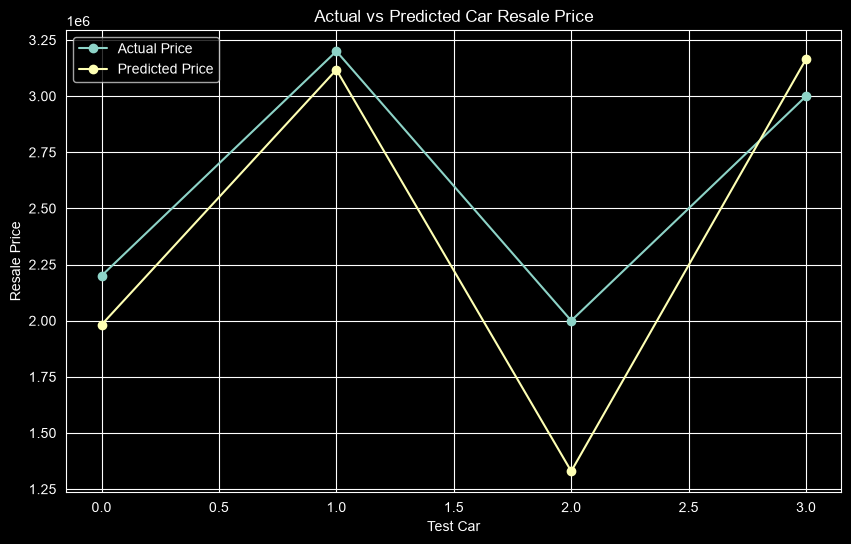

In [75]:
# ============================================================
# MODEL EVALUATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# 1. MAKE PREDICTIONS
# ------------------------------------------------------------

predictions = model.predict(X_test)

print("Predictions:")
print(predictions)


# ------------------------------------------------------------
# 2. CALCULATE EVALUATION METRICS
# ------------------------------------------------------------

mae = mean_absolute_error(Y_test, predictions)

mse = mean_squared_error(Y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(Y_test, predictions)


# ------------------------------------------------------------
# 3. DISPLAY MODEL PERFORMANCE
# ------------------------------------------------------------

print("\n========== MODEL EVALUATION ==========")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)


# ------------------------------------------------------------
# 4. ACTUAL VS PREDICTED TABLE
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Actual Price": Y_test.values,
    "Predicted Price": predictions
})

print("\n========== ACTUAL VS PREDICTED ==========")

print(comparison)


# ------------------------------------------------------------
# 5. COMPARISON GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    range(len(Y_test)),
    Y_test.values,
    marker="o",
    label="Actual Price"
)

plt.plot(
    range(len(predictions)),
    predictions,
    marker="o",
    label="Predicted Price"
)

plt.xlabel("Test Car")
plt.ylabel("Resale Price")

plt.title("Actual vs Predicted Car Resale Price")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
~~~~~~~~